In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Load your files
data = pd.read_csv("data1.csv")
output = pd.read_csv("output.csv")

# Combine if needed (depends on your dataset)
df = pd.concat([data, output], axis=1)

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,...,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,...,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,...,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,...,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,...,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 36 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
 18  date           4600

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [10]:
# Simple method (for internship level)
df = df.fillna(df.mean(numeric_only=True))
print(df)

                     date         price  bedrooms  bathrooms  sqft_living  \
0     2014-05-02 00:00:00  3.130000e+05       3.0       1.50         1340   
1     2014-05-02 00:00:00  2.384000e+06       5.0       2.50         3650   
2     2014-05-02 00:00:00  3.420000e+05       3.0       2.00         1930   
3     2014-05-02 00:00:00  4.200000e+05       3.0       2.25         2000   
4     2014-05-02 00:00:00  5.500000e+05       4.0       2.50         1940   
...                   ...           ...       ...        ...          ...   
4595  2014-07-09 00:00:00  3.081667e+05       3.0       1.75         1510   
4596  2014-07-09 00:00:00  5.343333e+05       3.0       2.50         1460   
4597  2014-07-09 00:00:00  4.169042e+05       3.0       2.50         3010   
4598  2014-07-10 00:00:00  2.034000e+05       4.0       2.00         2090   
4599  2014-07-10 00:00:00  2.206000e+05       3.0       2.50         1490   

      sqft_lot  floors  waterfront  view  condition  ...  view  condition  

In [8]:
print(df.columns)

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country', 'date', 'price', 'bedrooms', 'bathrooms',
       'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street',
       'city', 'statezip', 'country'],
      dtype='str')


In [9]:
X = df.drop("price", axis=1)
y = df["price"]

In [11]:
X = pd.get_dummies(X, drop_first=True)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train, X_test, y_train, y_test)


      bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
1898       4.0       2.50         2770     45514     2.0           0     0   
1370       4.0       3.00         3720     29043     2.0           0     0   
3038       4.0       2.50         2810     11120     2.0           0     0   
2361       4.0       3.75         4030     10800     2.0           0     0   
156        3.0       2.00         2000      7000     2.0           0     0   
...        ...        ...          ...       ...     ...         ...   ...   
4426       3.0       1.00         1180      5002     1.5           0     0   
466        4.0       2.00         2520      6000     1.0           0     0   
3092       3.0       1.00         1150      8145     1.0           0     0   
3772       2.0       1.00          910      2002     1.5           0     0   
860        2.0       1.00         1490      3825     1.0           0     0   

      condition  sqft_above  sqft_basement  ...  statezip_WA 98

In [16]:
X_simple = df[["sqft_living"]]
y_simple = df["price"]
print(X_simple,y_simple)

      sqft_living  sqft_living
0            1340         1340
1            3650         3650
2            1930         1930
3            2000         2000
4            1940         1940
...           ...          ...
4595         1510         1510
4596         1460         1460
4597         3010         3010
4598         2090         2090
4599         1490         1490

[4600 rows x 2 columns]              price         price
0     3.130000e+05  3.130000e+05
1     2.384000e+06  2.384000e+06
2     3.420000e+05  3.420000e+05
3     4.200000e+05  4.200000e+05
4     5.500000e+05  5.500000e+05
...            ...           ...
4595  3.081667e+05  3.081667e+05
4596  5.343333e+05  5.343333e+05
4597  4.169042e+05  4.169042e+05
4598  2.034000e+05  2.034000e+05
4599  2.206000e+05  2.206000e+05

[4600 rows x 2 columns]


In [15]:
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)
print(Xs_train, Xs_test, ys_train, ys_test)

      sqft_living  sqft_living
1898         2770         2770
1370         3720         3720
3038         2810         2810
2361         4030         4030
156          2000         2000
...           ...          ...
4426         1180         1180
466          2520         2520
3092         1150         1150
3772          910          910
860          1490         1490

[3680 rows x 2 columns]       sqft_living  sqft_living
3683         1460         1460
4411         2000         2000
2584         2940         2940
69           2200         2200
1844         1720         1720
...           ...          ...
1612         1700         1700
1068         1930         1930
4350         1180         1180
3027         2370         2370
3455         2260         2260

[920 rows x 2 columns]              price         price
1898  6.850000e+05  6.850000e+05
1370  8.570000e+05  8.570000e+05
3038  6.750000e+05  6.750000e+05
2361  1.485000e+06  1.485000e+06
156   5.610000e+05  5.610000e+05
...      

In [17]:
model_simple = LinearRegression()
model_simple.fit(Xs_train, ys_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
ys_pred = model_simple.predict(Xs_test)
print(ys_pred)

[[364099.731299   364099.731299  ]
 [508405.99719432 508405.99719432]
 [759605.79338245 759605.79338245]
 ...
 [289274.26009403 289274.26009403]
 [607282.51271518 607282.51271518]
 [577886.79188465 577886.79188465]]


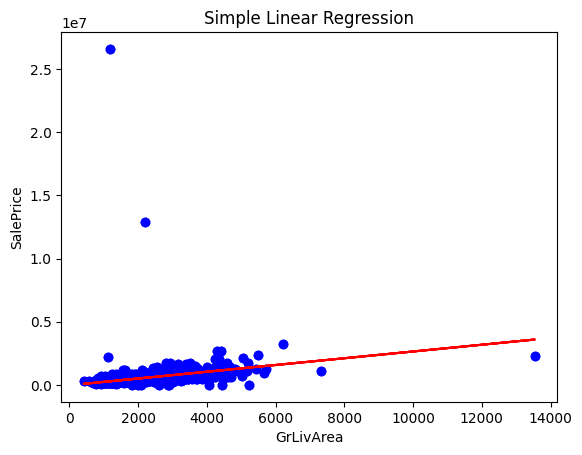

In [20]:
plt.scatter(Xs_test, ys_test, color="blue")
plt.plot(Xs_test, ys_pred, color="red")
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("Simple Linear Regression")
plt.show()

In [21]:
mse_simple = mean_squared_error(ys_test, ys_pred)
r2_simple = r2_score(ys_test, ys_pred)

print("Simple Model MSE:", mse_simple)
print("Simple Model R2:", r2_simple)

Simple Model MSE: 990205002761.5997
Simple Model R2: 0.02906451311363989


In [23]:
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
y_pred = model_multi.predict(X_test)
print(y_pred)

[[ 506362.72797482  506362.72797482]
 [ 343875.33763096  343875.33763096]
 [1216850.98004778 1216850.98004778]
 ...
 [-235108.3470661  -235108.3470661 ]
 [ 378346.36564666  378346.36564666]
 [ 167904.36321621  167904.36321621]]


In [25]:
mse_multi = mean_squared_error(y_test, y_pred)
r2_multi = r2_score(y_test, y_pred)

print("Multiple Model MSE:", mse_multi)
print("Multiple Model R2:", r2_multi)

Multiple Model MSE: 1157248463653.1296
Multiple Model R2: -0.13472826068529087


In [26]:
print("Simple R2:", r2_simple)
print("Multiple R2:", r2_multi)

Simple R2: 0.02906451311363989
Multiple R2: -0.13472826068529087


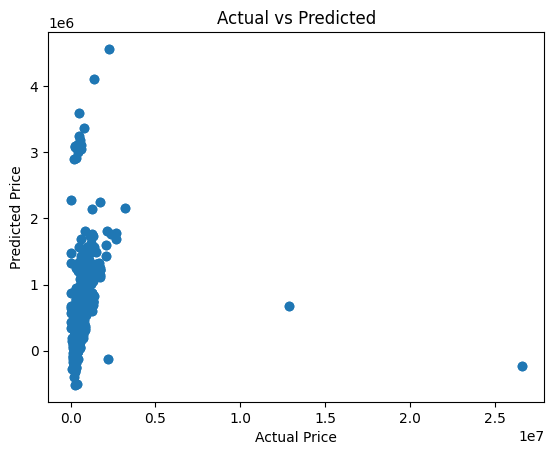

In [ ]:
y_test = y_test.values.ravel()
y_pred = y_pred.ravel()
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

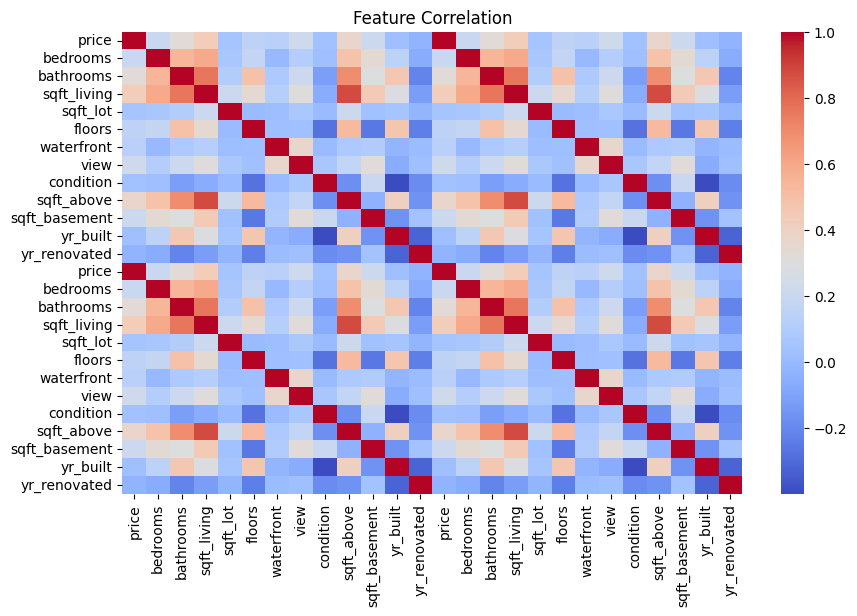

In [34]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(), cmap="coolwarm")

plt.title("Feature Correlation")
plt.show()